In [1]:
import os                   
import tensorflow as tf                                  
import keras                                               
import numpy as np                                                              
import pandas as pd                                                             
import scipy                                               
from scipy import stats                                                       
import matplotlib.pyplot as plt                            
import seaborn as sns                                                           
import time                                                
import json                                               

Tensorflow: 2.21.0 | Keras: 3.15.1
numpy: 2.5.3
pandas: 2.3.3
scipy: 1.18.1
seaborn: 0.13.2


In [2]:
# Plot and display settings used in every notebook
def jupyter_settings():
    plt.style.use('seaborn-v0_8-whitegrid')
    plt.rcParams.update({
        'figure.figsize': (12, 6),
        'figure.dpi': 100,
        'axes.titlesize': 14,
        'axes.labelsize': 12,
        'legend.fontsize': 10,
        'xtick.labelsize': 10,
        'ytick.labelsize': 10,
        'savefig.bbox': 'tight',
        'savefig.dpi': 120
    })
    pd.set_option('display.max_columns', 30)
    pd.set_option('display.float_format', '{:,.2f}'.format)

jupyter_settings()

In [3]:
# Paths used in this notebook
NN_DIR = os.path.expanduser('~/ca1/data/nn')         # extracts written in notebook 03
RESULTS = os.path.expanduser('~/ca1/results')
FIGURES = os.path.expanduser('~/ca1/figures')
GRID_FILE = f'{RESULTS}/04_grid_results.csv'          # one row per training, written as soon as it finishes

# Read the configuration frozen in notebook 03
with open(f'{RESULTS}/03_final_config.json') as f:
    frozen = json.load(f)
FINAL = frozen['final_config']
Y_SCALE, BATCH, EPOCHS, PATIENCE = frozen['y_scale'], frozen['batch'], frozen['epochs'], frozen['patience']
print(json.dumps(frozen, indent=2))

##### Specify parameters
SEEDS = list(range(1234, 1244))     # 10 seeds fixed before running: with fewer, the Holm-corrected Wilcoxon test can never reach p < 0.05
RESET_GRID = False                  # True deletes previous results and starts again; False resumes where it stopped

# Model levels: name -> (storage level from notebook 02, label used for training and validation)
MODEL_LEVELS = {
    'L0':     ('L0_native',    'duration_s_true'),   # reference
    'L1_f32': ('L1_float32',   'duration_s_true'),   # control
    'D1':     ('D1_dist_1dec', 'duration_s_true'),   # distance with 1 decimal
    'D0':     ('D0_dist_0dec', 'duration_s_true'),   # distance in whole miles
    'T1':     ('T1_ts_1min',   'duration_s_true'),   # timestamps to the minute, true label kept
    'T15':    ('T15_ts_15min', 'duration_s_true'),   # timestamps to 15 minutes, true label kept
    'T1L':    ('T1_ts_1min',   'label_ts'),          # timestamps to the minute, label computed from them
    'T15L':   ('T15_ts_15min', 'label_ts'),          # timestamps to 15 minutes, label computed from them
}

keras.utils.set_random_seed(SEEDS[0])
tf.config.experimental.enable_op_determinism()      # same seed, same result: the run can be repeated in front of an examiner

{
  "final_config": {
    "zone_mode": "embedding"
  },
  "best_phase": "P2",
  "seed": 1234,
  "train_buckets": 200,
  "eval_buckets": 200,
  "y_scale": 600.0,
  "batch": 1024,
  "epochs": 100,
  "patience": 5
}


In [4]:
# Read an extract and split it into train, validation and test
def load_level(name):
    data = pd.read_parquet(f'{NN_DIR}/{name}')
    data = data.sort_values('trip_id').reset_index(drop=True)      # same row order at every level, so the same seed gives the same batches
    return {s: data[data['split'] == s].reset_index(drop=True) for s in ['train', 'validation', 'test']}

# Turn a dataframe into the inputs of the network
def to_inputs(data, zone_mode):
    num = data[['dist_z', 'hour_sin_z', 'hour_cos_z']].to_numpy('float32')
    dow = np.eye(7, dtype='float32')[data['dow'].to_numpy()]                 # one-hot day of week
    if zone_mode == 'numeric':
        zones = data[['PULocationID', 'DOLocationID']].to_numpy('float32') / 265.0
        return {'Input-Numeric': np.hstack([num, dow, zones])}
    return {'Input-Numeric': np.hstack([num, dow]),
            'Input-PU-Zone': data['PULocationID'].to_numpy('int32'),
            'Input-DO-Zone': data['DOLocationID'].to_numpy('int32')}

# Build and compile the network (same function as notebook 03)
def build_model(zone_mode='embedding', hidden=(64, 32), dropout=0.0, emb_dim=8, lr=1e-3):
    n_num = 12 if zone_mode == 'numeric' else 10
    num_in = keras.Input(shape=(n_num,), name='Input-Numeric')                        # Input Layer for the numeric features
    inputs, parts = [num_in], [num_in]
    if zone_mode == 'embedding':
        pu_in = keras.Input(shape=(), dtype='int32', name='Input-PU-Zone')            # Input Layer for the pickup zone id
        do_in = keras.Input(shape=(), dtype='int32', name='Input-DO-Zone')            # Input Layer for the dropoff zone id
        zone_emb = keras.layers.Embedding(input_dim=266, output_dim=emb_dim, name='Zone-Embedding')   # one shared table for origin and destination
        parts += [zone_emb(pu_in), zone_emb(do_in)]
        inputs += [pu_in, do_in]
    x = keras.layers.Concatenate(name='Concatenate-Layer')(parts)                     # joins all inputs in one vector
    for i, units in enumerate(hidden, start=1):
        x = keras.layers.Dense(units, activation='relu', name=f'Hidden-Layer-{i}')(x) # Hidden Layer
        if dropout > 0:
            x = keras.layers.Dropout(dropout, name=f'Dropout-Layer-{i}')(x)
    out = keras.layers.Dense(1, activation='linear', name='Output-Layer')(x)          # Output Layer, one value: the duration
    model = keras.Model(inputs=inputs, outputs=out, name='MLP-Duration-Model')
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr),   # algorithm used in backpropagation
                  loss='mean_squared_error',                           # loss function to be optimized
                  metrics=['mean_absolute_error'])                     # metric reported every epoch
    return model

# Train one configuration and score it against the real duration (same function as notebook 03)
def train_eval(data, cfg, seed, label='duration_s_true', n_train=None, eval_split='validation'):
    keras.utils.set_random_seed(seed)
    train = data['train'] if n_train is None else data['train'].iloc[:n_train]
    X_train, y_train = to_inputs(train, cfg['zone_mode']), train[label].to_numpy('float32') / Y_SCALE
    X_val, y_val = to_inputs(data['validation'], cfg['zone_mode']), data['validation'][label].to_numpy('float32') / Y_SCALE   # same (possibly lossy) label as training
    model = build_model(**{k: v for k, v in cfg.items() if k in ('zone_mode', 'hidden', 'dropout', 'emb_dim', 'lr')})
    early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=PATIENCE, restore_best_weights=True)

    t0 = time.perf_counter()
    history = model.fit(x=X_train,                          # input data
                        y=y_train,                          # target data
                        batch_size=BATCH,                   # number of samples per gradient update
                        epochs=EPOCHS,                      # upper limit; early stopping ends the training before
                        verbose=0,                          # silent; one summary line is printed after training
                        callbacks=[early_stop],             # list of callbacks applied during training
                        validation_data=(X_val, y_val),     # temporal validation split (1 to 15 March)
                        shuffle=True)                       # reshuffles the training rows every epoch (controlled by the seed)
    train_s = time.perf_counter() - t0

    ev = data[eval_split]
    pred = model.predict(to_inputs(ev, cfg['zone_mode']), batch_size=8192, verbose=0).ravel() * Y_SCALE
    y_true = ev['duration_s_true'].to_numpy('float64')     # always scored against the real duration
    err = pred - y_true
    mse = (err ** 2).mean()
    res = {'MAE': np.abs(err).mean(), 'MSE': mse, 'RMSE': np.sqrt(mse),
           'R2': 1 - (err ** 2).sum() / ((y_true - y_true.mean()) ** 2).sum(),
           'Epochs': len(history.history['loss']), 'Train s': train_s}
    return res, history.history, model

In [5]:
# Start again or resume the grid
if RESET_GRID and os.path.exists(GRID_FILE):
    os.remove(GRID_FILE)
done = pd.read_csv(GRID_FILE) if os.path.exists(GRID_FILE) else pd.DataFrame(columns=['Level', 'Seed'])
print('Trainings already done:', len(done), 'of', len(MODEL_LEVELS) * len(SEEDS))

# Train every level with every seed, scored on the test split
t_grid = time.perf_counter()
n_new = 0
for level, (storage, label) in MODEL_LEVELS.items():
    data = load_level(storage)                                          # one level in memory at a time
    for seed in SEEDS:
        if ((done['Level'] == level) & (done['Seed'] == seed)).any():
            continue                                                    # already trained in a previous run
        res, _, _ = train_eval(data, FINAL, seed, label=label, eval_split='test')   # test split used here for the first and only time
        row = pd.DataFrame([{'Level': level, 'Seed': seed, **res}])
        row.to_csv(GRID_FILE, mode='a', header=not os.path.exists(GRID_FILE), index=False)   # saved at once: nothing is lost if the run stops
        n_new += 1
        elapsed = time.perf_counter() - t_grid
        remaining = len(MODEL_LEVELS) * len(SEEDS) - len(done) - n_new
        print(f"{level:7} seed {seed} | MAE {res['MAE']:7.1f} s | epochs {res['Epochs']:3d} | {res['Train s']:5.0f} s | "
              f"approx. {elapsed / n_new * remaining / 60:5.0f} min left")
    del data

grid_df = pd.read_csv(GRID_FILE)
print('Trainings in the results file:', len(grid_df))

Trainings already done: 80 of 80
Trainings in the results file: 80


In [6]:
# Mean and standard deviation of every metric by level, in the order of MODEL_LEVELS
LEVEL_ORDER = list(MODEL_LEVELS.keys())
summary_df = (grid_df.groupby('Level')[['MAE', 'RMSE', 'R2', 'Epochs', 'Train s']]
              .agg(['mean', 'std']).loc[LEVEL_ORDER])
summary_df

MAE        RMSE        R2      Epochs       Train s       
         mean  std   mean  std mean  std   mean   std    mean    std
Level                                                               
L0     185.81 1.39 321.87 3.35 0.83 0.00  42.00 15.35  629.14 241.56
L1_f32 186.11 1.23 322.11 3.37 0.82 0.00  36.80 11.39  497.14 165.67
D1     186.24 1.40 321.92 3.49 0.83 0.00  39.80 16.48  405.88 168.16
D0     197.93 1.36 329.28 2.70 0.82 0.00  46.10 18.13  470.36 188.70
T1     185.44 1.31 321.38 3.23 0.83 0.00  53.70 16.92  547.39 168.32
T15    185.87 1.44 321.64 2.75 0.83 0.00  44.90 15.13  459.85 151.76
T1L    185.99 1.45 321.64 3.55 0.83 0.00  40.50 20.35  414.75 202.39
T15L   186.65 1.44 324.03 2.43 0.82 0.00  50.90 11.72  706.62 191.08

In [7]:
# MAE of every seed (rows) at every level (columns): the paired design
mae_df = grid_df.pivot(index='Seed', columns='Level', values='MAE')[LEVEL_ORDER]
mae_df

Level,L0,L1_f32,D1,D0,T1,T15,T1L,T15L
Seed,,,,,,,,
1234,184.40,184.93,184.65,196.89,184.10,184.67,184.82,186.81
1235,185.11,185.84,186.09,197.67,185.61,186.25,185.41,185.42
1236,187.12,186.44,187.09,200.40,185.73,187.39,186.33,189.58
1237,183.70,183.42,184.25,195.25,182.64,183.18,183.36,185.14
1238,186.94,186.80,187.42,198.10,186.05,186.41,187.31,185.40
1239,185.78,186.08,185.53,197.27,185.26,184.14,185.83,186.84
1240,185.53,186.39,186.18,197.82,185.56,185.75,186.02,185.57
1241,186.68,187.03,186.81,198.87,186.90,187.58,186.82,188.45
1242,184.73,186.23,185.44,198.27,185.34,186.43,185.35,186.25


In [8]:
# Compare every level with L0, seed by seed
tests = []
for level in LEVEL_ORDER[1:]:
    d = mae_df[level] - mae_df['L0']                                          # paired differences, one per seed
    if np.allclose(d, 0):                                                     # identical results: no test is possible or needed
        tests.append([level, 0.0, 0.0, 0.0, 0.0, 0.0, np.nan, 1.0, 1.0, 'none (identical)', 1.0])
        continue
    shapiro_p = stats.shapiro(d).pvalue                                       # normality of the differences (assumption of the t-test)
    wilcoxon_p = stats.wilcoxon(d).pvalue                                     # non-parametric paired test, exact for 10 pairs
    ttest_p = stats.ttest_rel(mae_df[level], mae_df['L0']).pvalue             # paired t-test, valid if the differences are normal
    ci_low, ci_high = stats.t.interval(0.95, len(d) - 1, loc=d.mean(), scale=stats.sem(d))   # 95% confidence interval of the mean difference
    effect = d.mean() / d.std(ddof=1)                                         # Cohen's dz: mean difference in standard deviations
    test_used, primary_p = ('paired t-test', ttest_p) if shapiro_p > 0.05 else ('Wilcoxon', wilcoxon_p)   # t-test only if the differences look normal
    tests.append([level, d.mean(), d.mean() / mae_df['L0'].mean() * 100, ci_low, ci_high, effect,
                  shapiro_p, wilcoxon_p, ttest_p, test_used, primary_p])

tests_df = pd.DataFrame(tests, columns=['Level', 'Mean diff s', 'Diff %', 'CI low', 'CI high', "Cohen's dz",
                                        'Shapiro p', 'Wilcoxon p', 't-test p', 'Test used', 'Primary p'])

# Holm correction: 7 comparisons with L0, so the threshold is tightened to avoid false positives
order = tests_df['Primary p'].sort_values().index
m = len(tests_df)
running_max = 0
holm = pd.Series(index=tests_df.index, dtype=float)
for rank, i in enumerate(order):
    running_max = max(running_max, min(1.0, (m - rank) * tests_df.loc[i, 'Primary p']))
    holm[i] = running_max
tests_df['Primary p (Holm)'] = holm
tests_df['Significant'] = tests_df['Primary p (Holm)'] < 0.05
tests_df.round(4)

,Level,Mean diff s,Diff %,CI low,CI high,Cohen's dz,Shapiro p,Wilcoxon p,t-test p,Test used,Primary p,Primary p (Holm),Significant
0,L1_f32,0.30,0.16,-0.17,0.76,0.46,0.94,0.16,0.18,paired t-test,0.18,0.55,False
1,D1,0.43,0.23,0.15,0.71,1.08,0.88,0.02,0.01,paired t-test,0.01,0.05,True
2,D0,12.12,6.52,11.46,12.77,13.23,0.91,0.00,0.00,paired t-test,0.00,0.00,True
3,T1,-0.37,-0.20,-0.87,0.13,-0.53,0.63,0.16,0.13,paired t-test,0.13,0.50,False
4,T15,0.05,0.03,-0.70,0.81,0.05,0.87,0.92,0.88,paired t-test,0.88,0.88,False
5,T1L,0.18,0.10,-0.14,0.50,0.40,0.07,0.19,0.24,paired t-test,0.24,0.55,False
6,T15L,0.84,0.45,-0.15,1.83,0.60,0.38,0.11,0.09,paired t-test,0.09,0.44,False


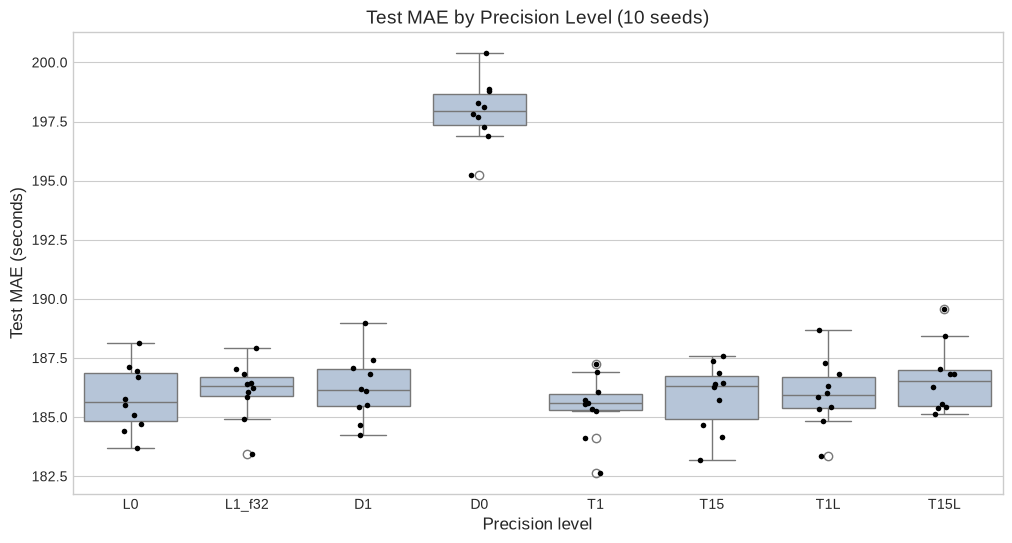

In [9]:
# Box plot of the test MAE for 10 seeds at every level
plt.figure(figsize=(12, 6))
long_df = mae_df.reset_index().melt(id_vars='Seed', var_name='Level', value_name='MAE')
sns.boxplot(data=long_df, x='Level', y='MAE', color='lightsteelblue', order=LEVEL_ORDER)
sns.stripplot(data=long_df, x='Level', y='MAE', color='black', size=4, order=LEVEL_ORDER)   # one dot per seed
plt.title('Test MAE by Precision Level (10 seeds)')
plt.xlabel('Precision level')
plt.ylabel('Test MAE (seconds)')
plt.savefig(f'{FIGURES}/04_mae_by_level.png')
plt.show()

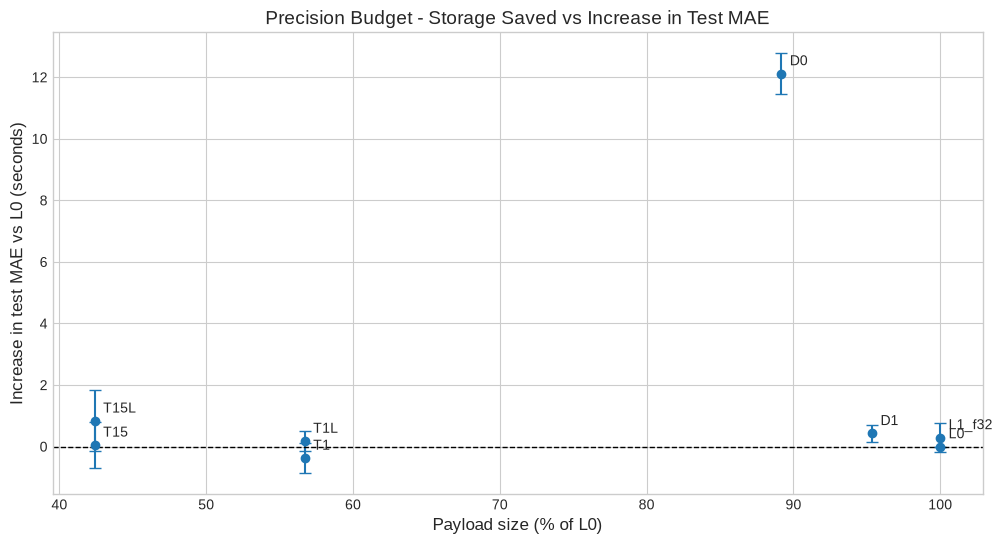

,Mean diff s,CI low,CI high,Storage %
Level,,,,
L0,0.00,0.00,0.00,100.00
L1_f32,0.30,-0.17,0.76,100.00
D1,0.43,0.15,0.71,95.36
D0,12.12,11.46,12.77,89.18
T1,-0.37,-0.87,0.13,56.72
T15,0.05,-0.70,0.81,42.41
T1L,0.18,-0.14,0.50,56.72
T15L,0.84,-0.15,1.83,42.41


In [10]:
## Storage left at each level (notebook 02) against the increase in error (this notebook)
storage = pd.read_csv(f'{RESULTS}/02_levels_summary.csv', index_col=0)
size_col = [c for c in storage.columns if 'L0' in c][0]       # 'Size vs L0 %' (or 'size_vs_L0_pct' in the first version of notebook 02)

budget_df = tests_df.set_index('Level')[['Mean diff s', 'CI low', 'CI high']].copy()
budget_df.loc['L0'] = [0.0, 0.0, 0.0]
budget_df['Storage %'] = [storage.loc[MODEL_LEVELS[lvl][0], size_col] for lvl in budget_df.index]
budget_df = budget_df.loc[LEVEL_ORDER]


## Plot precision Budget - Storage Saved x Increase in Test MAE 
plt.figure(figsize=(12, 6))
plt.errorbar(budget_df['Storage %'], budget_df['Mean diff s'],
             yerr=[budget_df['Mean diff s'] - budget_df['CI low'], budget_df['CI high'] - budget_df['Mean diff s']],
             fmt='o', capsize=4)                                                   # 95% confidence interval of each level
for lvl, row in budget_df.iterrows():
    plt.annotate(lvl, (row['Storage %'], row['Mean diff s']), textcoords='offset points', xytext=(6, 6))
plt.axhline(0, color='black', linestyle='--', linewidth=1)                          # no change in error
plt.title('Precision Budget - Storage Saved vs Increase in Test MAE')
plt.xlabel('Payload size (% of L0)')
plt.ylabel('Increase in test MAE vs L0 (seconds)')
plt.savefig(f'{FIGURES}/04_precision_budget.png')
plt.show()
budget_df

In [11]:
# Save the results in a CSV. 
summary_df.to_csv(f'{RESULTS}/04_summary_by_level.csv')
tests_df.to_csv(f'{RESULTS}/04_paired_tests.csv', index=False)
budget_df.to_csv(f'{RESULTS}/04_precision_budget.csv')
